About this notebook.

This notebook goes through all the texts and aplies on them a NLP pipeline consisting of (1) cleaning of the raw text, (2) sentence tokenization, (3) part-of-speech annotation, (4) lemmatization, and (5) named entity recognition.

The processed textual data are saved for future reuse.

In [1]:
import spacy
import os
import glob
from spacy.tokens import Doc
from spacy.language import Language
import pickle
from unidecode import unidecode
import sddk
import pandas as pd
import re
import sys
import importlib
import json
from spacy.tokens import Token
from spacy.language import Language
import google_conf
import pandas as pd
import json
import fitz
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

In [2]:
emlap_catalogue = google_conf.setup(sheet_url="https://docs.google.com/spreadsheets/d/1QfepoyysD1Cu12KcMAMfc6gqGzXzVUekPtXDbxLixr4/edit?usp=sharing", service_account_path="../../../ServiceAccountsKey.json")

In [3]:
import stanza
#stanza.download("grc")

/home/jupyter-vojta/notebooks/labyrinth/venv_torch_nlp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
emlap_metadata = pd.read_csv("../data/emlap_metadata.csv", sep=";", index_col=0)
emlap_metadata.head(5)

,working_title,filenames,no.,is_done,is_noscemus,if_noscemus_id,AUTHORSHIP,is_one_author,#if more than 1 author skip section and choose compendium below,is_author_known,...,CONTENTS,genre,subject,SOURCE OF FILE,link,source_of_file,origin_of_copy,other_notes,tokens_N,aurhor_wd
0,"Augurello, Chrysopoeia",100001_Augurello1515_Chrysopoeia_GB_Noscemus,100001,True,True,713324.0,NaN,True,NaN,True,...,NaN,didactic poem,alchemy,NaN,https://wiki.uibk.ac.at/noscemus/Chrysopoeia,GB,Noscemus,NaN,23718,NaN
1,"Pseudo-Lull, Secretis",100002_Pseudo-Lull1518_De secretis_naturae_MDZ...,100002,True,False,NaN,NaN,True,NaN,True,...,NaN,treatise,"alchemy, medicine",NaN,https://www.digitale-sammlungen.de/en/view/bsb...,MDZ,MBS,NaN,24673,NaN
2,"Pantheus, Ars Transmutatione",100003_Pantheus1518_Ars_Transmutationis_Metall...,100003,True,False,NaN,NaN,True,NaN,True,...,NaN,treatise,alchemy,NaN,https://www.google.co.uk/books/edition/Ars_Tra...,GB,BL,NaN,8646,NaN
3,"Anon, Vera alchemiae",100004_Anon1561_Verae_Alchemiae_MDZ_MBS,100004,True,False,NaN,NaN,True,NaN,True,...,NaN,"compendium, florilegium",alchemy,NaN,https://mdz-nbn-resolving.de/details:bsb10141168,MDZ,MBS,NaN,3521,NaN
4,"Pantheus, Voarchadumia",100005_Pantheus1530_Voarchadumia_ONB,100005,True,False,NaN,NaN,True,NaN,True,...,NaN,treatise,alchemy,NaN,https://data.onb.ac.at/rep/10588E49,ONB,ONB,NaN,20386,NaN


In [5]:
row = emlap_metadata.loc[emlap_metadata["no."]==100001].iloc[0]

In [6]:
row["working_title"]

'Augurello, Chrysopoeia'

In [7]:
import json
import ast
import re

def parse_messy_json(text):
    if not isinstance(text, str):
        return None

    # 1. Try strict JSON first
    try:
        return json.loads(text)
    except Exception:
        pass

    # 2. Fix common issues
    fixed = text.strip()

    # Replace single quotes with double quotes when appropriate
    fixed = fixed.replace("'", '"')

    # Remove trailing commas before ] or }
    fixed = re.sub(r",\s*([}\]])", r"\1", fixed)

    # Ensure keys are quoted (naively, but works for your case)
    fixed = re.sub(r"(?<=\{|\s)([A-Za-z_][A-Za-z0-9_]*)(?=\s*:)", r'"\1"', fixed)

    # 3. Try JSON again
    try:
        return json.loads(fixed)
    except Exception:
        pass

    # 4. Try Python literal (safer than eval)
    try:
        return ast.literal_eval(text)
    except Exception:
        pass

    # 5. Give up
    return None

In [8]:
emlap_metadata["if_compendium_parsed"] = emlap_metadata["if_compendium"].apply(parse_messy_json).tolist()

In [9]:
len(emlap_metadata)

100

In [10]:
#filename_id_dict = dict(zip(emlap_metadata["filename"], emlap_metadata["No."]))

For preprocessing the latin texts, we will use a module located outside of the current repository, specifically at the same level one level up.

The module can be clonned from here: https://github.com/CCS-ZCU/latin-preprocessing and imported to python following the steps below:

In [11]:
import spacy_stanza

In [12]:
greek_nlp = spacy_stanza.load_pipeline("grc")

2025-12-01 22:12:18 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-12-01 22:12:19 INFO: Loading these models for language: grc (Ancient_Greek):
| Processor | Package         |
-------------------------------
| tokenize  | proiel          |
| pos       | proiel_nocharlm |
| lemma     | proiel_nocharlm |
| depparse  | proiel_nocharlm |

2025-12-01 22:12:19 INFO: Using device: cuda
2025-12-01 22:12:19 INFO: Loading: tokenize
2025-12-01 22:12:19 INFO: Loading: pos
2025-12-01 22:12:19 INFO: Loading: lemma
2025-12-01 22:12:20 INFO: Loading: depparse
2025-12-01 22:12:20 INFO: Done loading processors!


In [13]:
doc = greek_nlp('δοκῶ μοι περὶ ὧν πυνθάνεσθε οὐκ ἀμελέτητος εἶναι')

for token in doc:
   print(f'{token.text}, lemma: {token.lemma_}, pos: {token.pos_}, dep: {token.dep_}')

δοκῶ, lemma: δοκέω, pos: VERB, dep: root
μοι, lemma: ἐγώ, pos: PRON, dep: obl:arg
περὶ, lemma: περί, pos: ADP, dep: case
ὧν, lemma: ὅς, pos: PRON, dep: obj
πυνθάνεσθε, lemma: πυνθάνομαι, pos: VERB, dep: acl
οὐκ, lemma: οὐ, pos: ADV, dep: advmod
ἀμελέτητος, lemma: ἀμελέτης, pos: NOUN, dep: ccomp
εἶναι, lemma: εἰμί, pos: AUX, dep: cop


In [14]:
# stanza.download("la")

In [45]:
stanzala = spacy_stanza.load_pipeline("xx", lang="la")

2025-12-01 22:16:26 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-12-01 22:16:26 INFO: Loading these models for language: la (Latin):
| Processor | Package       |
-----------------------------
| tokenize  | ittb          |
| pos       | ittb_nocharlm |
| lemma     | ittb_nocharlm |
| depparse  | ittb_nocharlm |

2025-12-01 22:16:26 INFO: Using device: cuda
2025-12-01 22:16:26 INFO: Loading: tokenize
2025-12-01 22:16:26 INFO: Loading: pos
2025-12-01 22:16:27 INFO: Loading: lemma
2025-12-01 22:16:27 INFO: Loading: depparse
2025-12-01 22:16:27 INFO: Done loading processors!


In [16]:
#!python -m spacy download de_core_news_sm

In [17]:
de_nlp = spacy.load("de_core_news_sm")   # or md/lg if you prefer
fr_nlp = spacy.load("fr_core_news_sm")

In [18]:
# for preprocessing the latin texts, we will use a module located outside of the current repository, specifically at the same level as the current project.
current_working_directory = os.getcwd()
relative_path = '../../latin-preprocessing/' # change according to your location...
module_path = os.path.abspath(os.path.join(current_working_directory, relative_path))
if module_path not in sys.path:
    sys.path.insert(0, module_path)
# Now import the module
import tomela

Using CPU for spaCy.


In [19]:
importlib.reload(tomela)

Using CPU for spaCy.


<module 'tomela' from '/home/jupyter-vojta/notebooks/latin-preprocessing/tomela/__init__.py'>

In [20]:
tomela.nlp.pipeline

[('senter', <spacy.pipeline.senter.SentenceRecognizer at 0x7902eb468050>),
 ('normer', <function la_core_web_lg.functions.normer(doc)>),
 ('tok2vec', <spacy.pipeline.tok2vec.Tok2Vec at 0x7902eb468170>),
 ('tagger', <spacy.pipeline.tagger.Tagger at 0x7902eb468290>),
 ('morphologizer',
  <spacy.pipeline.morphologizer.Morphologizer at 0x7902eb4681d0>),
 ('trainable_lemmatizer',
  <spacy.pipeline.edit_tree_lemmatizer.EditTreeLemmatizer at 0x7902eb468230>),
 ('parser', <spacy.pipeline.dep_parser.DependencyParser at 0x7902eb5b57e0>),
 ('lookup_lemmatizer',
  <function la_core_web_lg.functions.make_lookup_lemmatizer_function(doc)>),
 ('ner', <spacy.pipeline.ner.EntityRecognizer at 0x7902eb5b5540>),
 ('remorpher', <function la_core_web_lg.functions.remorpher(doc)>)]

In [21]:
tomela.nlp.max_length = 4000000

In [22]:
doc = tomela.nlp("Veritas, vt vlla dicit, semper est universalis et a principiis fundamentalis oritur (lib. 3, cap. VI)")
for token in doc:
    print((token.text, token.lemma_, token.pos_))

('Veritas', 'ueritas', 'NOUN')
(',', ',', 'PUNCT')
('vt', 'vt', 'ADV')
('vlla', 'vllus', 'NOUN')
('dicit', 'dico', 'VERB')
(',', ',', 'PUNCT')
('semper', 'semper', 'ADV')
('est', 'sum', 'AUX')
('universalis', 'uniuersalis', 'ADJ')
('et', 'et', 'CCONJ')
('a', 'ab', 'ADP')
('principiis', 'principium', 'NOUN')
('fundamentalis', 'fundamentalis', 'ADJ')
('oritur', 'orior', 'VERB')
('(lib', '(lib', 'NOUN')
('.', '.', 'PUNCT')
('3', '3', 'NUM')
(',', ',', 'PUNCT')
('cap', 'capitulum', 'NOUN')
('.', '.', 'PUNCT')
('VI', 'uis', 'NUM')
(')', ')', 'PUNCT')


In [23]:
source_path = "/srv/data/tome/tome-corpus/EMLAP_2025-10-31/annotated_textblocks/"
len(os.listdir(source_path))

200

In [24]:
import shutil
shutil.copytree("/srv/data/tome/tome-corpus/EMLAP_2025-10-31/annotated_textblocks/", "../data/emlap_annotated_textblocks/", dirs_exist_ok=True)

'../data/emlap_annotated_textblocks/'

In [25]:
[f for f in sorted(os.listdir(source_path)) if "_params" not in f]

['100001_Augurello1515_Chrysopoeia_GB_Noscemus.json',
 '100002_Pseudo-Lull1518_De_secretis_naturae_MDZ_MBS.json',
 '100003_Pantheus1518_Ars_Transmutationis_Metallicae_BL_GB.json',
 '100004_Anon1561_Verae_Alchemiae_MDZ_MBS.json',
 '100005_Pantheus1530_Voarchadumia_ONB.json',
 '100006_Savonarola1532_De_arte_conficiendi_aquam_vitae_ONB.json',
 '100007_Anon1550_Rosarium_philosophorum_ER_ZZ.json',
 '100008_Severinus1572_Epistola_MBZ_MBS.json',
 '100009_Vegius1518_Inter_inferiora_corpora_disputatio_ONB.json',
 '100010_Bracesco1548_De_alchemia_dialogi_duo_IA_Madrid.json',
 '100011_Anon1541_De_alchemia_MDZ_MBS.json',
 '100012_Gessner1552_Thesaurus_Euonymi_Philiatri_ER_ZZ.json',
 '100013_Ulstad1525_Coelum_philosophorum_Medica_BIUSP.json',
 '100014_Toxites1567_Spongia_stibii_MDZ_MBS.json',
 '100015_Gessner1569_Thesaurus_Euonymi_Philiatri_liber_secundus_MDZ_MBS.json',
 '100016_Bonus1546_Pretiosa_Margarita_Novella_ONB.json',
 '100017_Bodenstein1559_Isagoge_MDZ_MBS.json',
 '100018_Trevisanus1567_Pe

In [26]:
row = emlap_metadata.loc[emlap_metadata["no."]==int("100001")].iloc[0]
row

working_title                                                                                 Augurello, Chrysopoeia
filenames                                                               100001_Augurello1515_Chrysopoeia_GB_Noscemus
no.                                                                                                           100001
is_done                                                                                                         True
is_noscemus                                                                                                     True
if_noscemus_id                                                                                              713324.0
AUTHORSHIP                                                                                                       NaN
is_one_author                                                                                                   True
#if more than 1 author skip section and choose compendium below 

In [27]:
files_overview = []
for filename in os.listdir(source_path):
    #filename = 'DuChesne1575_Ad_Iacobi_Auberti_MDZ_Augsburg.json'
    id = int(filename[:6])
    row = emlap_metadata.loc[emlap_metadata["no."]==id].iloc[0]
    if "_params" not in filename:
        filepath = os.path.join(source_path, filename)
        with open(filepath, 'r', encoding='utf-8') as f:
            textblocks = json.load(f)
        pages_n = len(textblocks)
        chars_n = sum([sum([len(tb["text"]) for tb in p]) for p in textblocks])
        files_overview.append({"filename" : filename, "pages_n" : pages_n, "chars_n" : chars_n})
files_processed = pd.DataFrame(files_overview)
files_processed

,filename,pages_n,chars_n
0,100084_Croll1609_Basilica_chymica_MDZ_MBS.json,477,694793
1,100094_Anon1625_Musaeum_hermeticum_VD17_SLUB.json,508,694493
2,100058_Hagecius1596_Actio_medica_ER_UBB.json,89,104677
3,100013_Ulstad1525_Coelum_philosophorum_Medica_...,113,237793
4,100069_Severinus1571_Idea_medicinae_philosophi...,463,600046
...,...,...,...
95,100056_Claveus1598_Apologia_crysopoeiae_MDZ_MB...,233,233328
96,100065_Libavius1594_Neoparacelsica_MDZ_MBS.json,821,1079977
97,100031_Phaedro1562_Aquila_coelestis_MBZ_MBS.json,55,15562
98,100098_Burggravius1630_Biolychnium_VD17_SLUB.json,167,186267


In [28]:
#emlap_catalogue = google_conf.setup(sheet_url="https://docs.google.com/spreadsheets/d/1bkHHTYc86K2IuEXqfYfkDNt5LovtvCU3gvqHIbVio88/edit?usp=sharing", service_account_path="../../../ServiceAccountsKey.json")

# google_conf.set_with_dataframe(emlap_catalogue.add_worksheet("files_processed", 1,1), files_processed, include_index=False)


Develop and test with one example test

In [217]:
filename = '100085_Libavius1606_Commentariorum_alchemiae_pars_1_MDZ_MBS.json'
filepath = os.path.join(source_path, filename)
with open(filepath, 'r', encoding='utf-8') as f:
    textblocks = json.load(f)

In [218]:
textblocks_unheadered = []
for p in textblocks:
    p_unheadered = []
    header_met = False
    for textblock in p:
        if textblock["tag"] == "header":
            if header_met:
                textblock["tag"] = "text"
            else:
                header_met = True
        p_unheadered.append(textblock)
    textblocks_unheadered.append(p_unheadered)

textblocks = textblocks_unheadered#%%
len(textblocks)

413

In [219]:
textblocks[30][:10]

[{'coordinates': [211.67999267578125,
   1086.2401123046875,
   361.0691833496094,
   1091.0400390625],
  'text': '6. Aeneid.\n',
  'tag': 'margin'},
 {'coordinates': [405.6000061035156,
   200.16000366210938,
   1988.2835693359375,
   217.34410095214844],
  'text': '20\nExamen sententiae Parisiensis scholae\n',
  'tag': 'header'},
 {'coordinates': [573.3599853515625,
   284.6640930175781,
   2086.989501953125,
   289.5841064453125],
  'text': '"Si in mundo sublunari nulla est substantia ab elementaribus quatuor distincta, nulla est quinta essen¬\n',
  'tag': 'text'},
 {'coordinates': [672.47998046875,
   334.7998962402344,
   1029.914794921875,
   339.5998840332031],
  'text': 'tia, quae extrahi possit.\n',
  'tag': 'text'},
 {'coordinates': [573.3599853515625,
   384.9600524902344,
   1760.6229248046875,
   389.7600402832031],
  'text': 'Prius est. Posterius ergo: & per consequens, ignis & opera perditur extrahendo,"\n',
  'tag': 'text'},
 {'coordinates': [504.9599914550781,
   433.6

In [220]:
margin_pages = []
for p in textblocks[:50]:
    for textblock in p:
        if textblock["tag"] == "margin":
            margin_pages.append(p)
            break

In [221]:
len(margin_pages)

35

In [222]:
margin_pages[0]

[{'coordinates': [235.44000244140625,
   684.7200317382812,
   409.4384460449219,
   689.5200805664062],
  'text': 'In specie tot\n',
  'tag': 'margin'},
 {'coordinates': [235.44000244140625,
   725.0398559570312,
   410.12158203125,
   729.8399047851562],
  'text': 'medicorum\n',
  'tag': 'margin'},
 {'coordinates': [235.44000244140625,
   765.8640747070312,
   409.9117736816406,
   770.7840576171875],
  'text': 'hodie sectae,\n',
  'tag': 'margin'},
 {'coordinates': [240.24000549316406,
   806.3999633789062,
   399.8396301269531,
   811.2000122070312],
  'text': 'vt videan¬\n',
  'tag': 'margin'},
 {'coordinates': [237.83999633789062,
   846.2639770507812,
   409.64459228515625,
   851.1839599609375],
  'text': 'tur innume¬\n',
  'tag': 'margin'},
 {'coordinates': [237.83999633789062,
   885.8640747070312,
   410.22802734375,
   890.7840576171875],
  'text': 'rabila, gene¬\n',
  'tag': 'margin'},
 {'coordinates': [237.83999633789062,
   929.0398559570312,
   394.5736389160156,
   933

In [223]:
margin_pages[1]

[{'coordinates': [526.0800170898438,
   172.10403442382812,
   1639.3897705078125,
   177.02403259277344],
  'text': 'EPISTOLA DEDICATORIA.\n',
  'tag': 'header'},
 {'coordinates': [337.9200134277344,
   262.1040344238281,
   1993.8466796875,
   267.0240478515625],
  'text': 'Nullus quidem Paracelsita quicquam sibi commune cum schola\n',
  'tag': 'text'},
 {'coordinates': [194.63999938964844,
   338.9038391113281,
   1991.999755859375,
   343.8238525390625],
  'text': 'Galenica esse prae se videtur ferre: aliqui tamen Hippocrati sunt aequio¬\n',
  'tag': 'text'},
 {'coordinates': [181.44000244140625,
   417.8399353027344,
   1995.948486328125,
   422.6399230957031],
  'text': 'res: Hic reijcit Chrysopoeian, ille magian, adiurationes, execrationes ec.\n',
  'tag': 'text'},
 {'coordinates': [185.75999450683594,
   495.3838195800781,
   1972.9329833984375,
   500.3038330078125],
  'text': 'Puri puti Paracelsici omnia atque etiam sputa sui Monarchae exosculan¬\n',
  'tag': 'text'},
 {'coor

In [224]:
for p in textblocks[:50]:
    for t in p:
        if "[" in t["text"]:
            print(t)

{'coordinates': [384.0, 2262.9599609375, 2165.489013671875, 2267.760009765625], 'text': '[GR]χιμικώτερα[/GR] essent seligere, dissentientiaquè componere. Itaque & nouam\n', 'tag': 'text'}
{'coordinates': [139.1999969482422, 3188.159912109375, 1914.183349609375, 3192.9599609375], 'text': 'quoddam [GR]μιγμα[/GR] & commentum ab omni veritate alienum. Sed ostendendum est veram artem nec\n', 'tag': 'text'}
{'coordinates': [398.1600036621094, 511.6800231933594, 2167.622314453125, 516.4800415039062], 'text': 'longe abest à [GR]πανσπερμία[/GR] illa vetere, & atomis Democriti, & multiplici vicissim oriente & pereunte? Sed\n', 'tag': 'text'}
{'coordinates': [390.7200012207031, 2782.079833984375, 2149.680419921875, 2786.8798828125], 'text': 'quętis [GR]σκευασταί καὶ πυροτεηνίαν[/GR], ecce tibi eundem Bulcasim passim inseruientem. Fornaces enim seu Atha¬\n', 'tag': 'text'}
{'coordinates': [198.24000549316406, 1149.1199951171875, 1980.812744140625, 1153.919921875], 'text': 'potest. "Nec ego (inquit

In [225]:
for p in textblocks:
    for t in p:
        if "[/S]" in t["text"]:
            print(t)

{'coordinates': [225.83999633789062, 905.7598266601562, 387.3038635253906, 910.5598754882812], 'text': 'Olei [S]y[/S]. j. ex\n', 'tag': 'margin'}
{'coordinates': [429.1199951171875, 1108.5599365234375, 2191.517578125, 1113.35986328125], 'text': 'crassos. Dosis eius solius [S]z[/S] ij. vsque ad [S]z[/S] iiij. cum aqua frigida. Similia habet Mesues lib simplicium, cap. 16.\n', 'tag': 'text'}
{'coordinates': [241.9199981689453, 2369.999755859375, 407.46197509765625, 2374.7998046875], 'text': 'trahe [S][/S], ex\n', 'tag': 'margin'}
{'coordinates': [234.72000122070312, 2417.999755859375, 407.2383728027344, 2422.7998046875], 'text': 'hoc\xa0[S][/S], & i¬\n', 'tag': 'margin'}
{'coordinates': [424.0799865722656, 312.7200622558594, 2143.775634765625, 317.5200500488281], 'text': 'Lunam, Venerem, Martem, Saturnum, louem; signare vero more astrologorum,\xa0[S]Mercurius[/S],\xa0[S]Sol[/S],\xa0[S]Luna[/S],\xa0[S]Venus[/S],\xa0[S]Mars[/S],\xa0[S]Saturnus[/S],\xa0[S]Jupiter[/S].\n', 'tag': 'text'}
{'c

In [226]:
for p in textblocks:
    for t in p:
        if "[G]" in t["text"]:
            print(t)

{'coordinates': [190.55999755859375, 3375.35986328125, 2012.520263671875, 3380.159912109375], 'text': 'tes quosdam de re rustica scriptores hanc indignam Philosophis seueris vocem: [G]Es ist vil besser daß das\n', 'tag': 'text'}
{'coordinates': [398.8800048828125, 577.9199829101562, 2197.105712890625, 582.7200317382812], 'text': 'decet addere, notum est. Appellant [G]gestub[/G] & eo focos instruunt, aliterque vtuntur. (Hinc illa phrasis\n', 'tag': 'text'}
{'coordinates': [398.8800048828125, 628.7998657226562, 2206.61669921875, 633.5999145507812], 'text': 'cum rumpitur stratum luteum & cinericium fulminatorii, aut fornacum excoctoriarum [G]das gestub\n', 'tag': 'text'}
{'coordinates': [117.36000061035156, 2250.479736328125, 1912.0018310546875, 2255.27978515625], 'text': '& testa, Germanice [G]auff dem Keest brennen[/G]. Abutuntur enim testae vocabulo propter aliquam similitu¬\n', 'tag': 'text'}
{'coordinates': [117.36000061035156, 2349.14404296875, 1911.837890625, 2354.06396484375], 'te

In [227]:
import re

SUPPORTED_LANG_TAGS = {"GR", "G", "F", "I", "H", "D"}
TAG_PATTERN = re.compile(r"\[(?P<open>[A-Za-z]+)]|\[/(?P<close>[A-Za-z]+)]")
S_PLACEHOLDER = "xyzxyzus"

# the real line-break continuation mark in your OCR
BREAK_HYPHEN = "¬"     # U+00AC

def sanitize_textblock(tb):
    """
    Fully sanitizes a single textblock strictly at markup level:
    - whitespace normalization
    - ensure tag pairs balance
    - fix S-tags differently from language tags
    - insert spacing to prevent token merges
    - remove space before punctuation (critical!)
    - FINAL: handle trailing break-hyphen vs space correctly
    """
    text = tb["text"]

    # ---------------------------------------------------------
    # 1. Normalize whitespace early
    # ---------------------------------------------------------
    text = text.replace("\xa0", " ")
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text)

    # SAFELY REMOVE DOUBLE BRACKETS (OCR NOISE)
    # Replace '[[something' → '[something' and ']]something' → ']something'
    text = text.replace("[[", "[")
    text = text.replace("]]", "]")

    # ---------------------------------------------------------
    # 2. Prepare for scanning & tag balancing
    # ---------------------------------------------------------
    out = []
    pos = 0

    lang_open = {L: 0 for L in SUPPORTED_LANG_TAGS}
    s_open = 0

    matches = list(TAG_PATTERN.finditer(text))

    for m in matches:
        start, end = m.span()

        out.append(text[pos:start])

        open_tag = m.group("open")
        close_tag = m.group("close")

        # -------------------------
        # 2A. Handle S-tags
        # -------------------------
        if open_tag == "S":
            s_open += 1
            out.append("[S]")
        elif close_tag == "S":
            if s_open == 0:
                out.append("[S]")
            else:
                s_open -= 1
            out.append("[/S]")

        # -------------------------
        # 2B. Handle language tags
        # -------------------------
        elif open_tag in SUPPORTED_LANG_TAGS:
            lang_open[open_tag] += 1
            out.append(f"[{open_tag}]")

        elif close_tag in SUPPORTED_LANG_TAGS:
            L = close_tag
            if lang_open[L] == 0:
                out.insert(0, f"[{L}]")
            else:
                lang_open[L] -= 1
            out.append(f"[/{L}]")

        pos = end

    out.append(text[pos:])
    sanitized = "".join(out)

    # ---------------------------------------------------------
    # 3. Fix empty S-spans
    # ---------------------------------------------------------
    sanitized = re.sub(r"\[S]\s*\[/S]", f"[S]{S_PLACEHOLDER}[/S]", sanitized)

    # ---------------------------------------------------------
    # 4. Close unclosed language openers
    # ---------------------------------------------------------
    for L, count in lang_open.items():
        if count > 0:
            sanitized += f"[/{L}]" * count

    # ---------------------------------------------------------
    # 5. Close unmatched S-openers
    # ---------------------------------------------------------
    sanitized = sanitized.replace("[S][/", "[S]xyzxyzus[/")
    while sanitized.count("[S]") > sanitized.count("[/S]"):
        sanitized += "[/S]"

    # ---------------------------------------------------------
    # 6. Insert safe spaces around all tags
    # ---------------------------------------------------------
    sanitized = sanitized.replace("[", " [")
    sanitized = sanitized.replace("]", "] ")
    sanitized = re.sub(r"\s+", " ", sanitized).strip()

    sanitized = re.sub(r"(\])(?! )", r"\1 ", sanitized)
    sanitized = re.sub(r"(?<! )(\[)", r" \1", sanitized)
    sanitized = re.sub(r"\s+", " ", sanitized)

    # ---------------------------------------------------------
    # 7. Remove space before punctuation
    # ---------------------------------------------------------
    sanitized = re.sub(r"\s+([.,;:!?\)])", r"\1", sanitized)

    # ---------------------------------------------------------
    # 8. FINAL BLOCK-BOUNDARY NORMALIZATION
    # ---------------------------------------------------------
    # (1) remove trailing spaces
    sanitized = sanitized.rstrip()

    # (2) if last char is the historical line-break hyphen "¬", drop it
    if sanitized.endswith(BREAK_HYPHEN):
        sanitized = sanitized[:-1]
    else:
        # (3) otherwise guarantee one trailing space
        sanitized = sanitized + " "

    # ---------------------------------------------------------
    # Done
    # ---------------------------------------------------------
    out_tb = dict(tb)
    out_tb["text"] = sanitized
    return out_tb


def sanitize_all_textblocks(textblocks):
    sanitized_pages = []
    for page in textblocks:
        sanitized_pages.append([sanitize_textblock(tb) for tb in page])
    return sanitized_pages

In [228]:
textblocks = sanitize_all_textblocks(textblocks)

In [229]:
textblocks[96][57]

{'coordinates': [421.9200134277344,
  3392.639892578125,
  2158.311767578125,
  3397.43994140625],
 'text': ' [S] xyzxyzus [/S] Sal (vel [S] Gemini [/S] [S] xyzxyzus [/S]) O antimonium (alias [S] xyzxyzus [/S] [S] xyzxyzus [/S] [S] xyzxyzus [/S]) ammoniacus (vel [S] xyzxyzus [/S]) [S] xyzxyzus [/S] oleum ',
 'tag': 'text'}

In [230]:
import re
import unicodedata
from spacy.tokens import Token, Doc
from spacy.language import Language
from spacy.symbols import ORTH


SYMBOL_PLACEHOLDER = "xyzxyzus"
S_OPEN  = "[S]"
S_CLOSE = "[/S]"

# =============================================================================
# 0. EXTERNAL MODELS (YOU MUST SUPPLY THEM)
# =============================================================================

nlp_latin = tomela.nlp       # your Latin model
importlib.reload(tomela)
nlp_latin = tomela.nlp       # your Latin model


import spacy
from spacy.tokenizer import Tokenizer
from spacy.util import compile_prefix_regex, compile_suffix_regex, compile_infix_regex

def rebuild_tokenizer_for_latin(nlp):
    prefixes = [r"\("] + list(nlp.Defaults.prefixes)
    suffixes = list(nlp.Defaults.suffixes)
    infixes  = list(nlp.Defaults.infixes)

    nlp.tokenizer = Tokenizer(
        nlp.vocab,
        prefix_search=compile_prefix_regex(prefixes).search,
        suffix_search=compile_suffix_regex(suffixes).search,
        infix_finditer=compile_infix_regex(infixes).finditer,
    )

# apply fix
rebuild_tokenizer_for_latin(nlp_latin)

# ❗ correct special case (single token)
nlp_latin.tokenizer.add_special_case(
    SYMBOL_PLACEHOLDER,
    [{ORTH: SYMBOL_PLACEHOLDER}]
)


LANG_PIPELINES = {
    "GR": greek_nlp,   # Greek
    "G":  de_nlp,      # German
    "F":  fr_nlp,      # French
}

SUPPORTED_LANGUAGE_TAGS = {"GR", "G", "F", "I", "H", "D"}
DEEP_PIPELINE_TAGS      = {"GR", "G", "F"}
SHALLOW_TAGS            = {"I", "H", "D"}

TAG_REGEX = re.compile(r"\[(?P<tag>[A-Za-z]+)]|\[/(?P<etag>[A-Za-z]+)]")
GREEK_RE  = re.compile(r"[\u0370-\u03FF\u1F00-\u1FFF]")



# =============================================================================
# 1. TOKEN / DOC EXTENSIONS
# =============================================================================

for ext, default in [
    ("pages", None),
    ("textblocks", None),
    ("tags", None),
    ("block_type", None),
]:
    if not Token.has_extension(ext):
        Token.set_extension(ext, default=default)

if not Token.has_extension("ml_data"):
    Token.set_extension("ml_data", default={})

if not Doc.has_extension("char_to_source"):
    Doc.set_extension("char_to_source", default=None)


# =============================================================================
# 2. LANGUAGE TAG EXTRACTION (ON PRESANITIZED TEXT)
# =============================================================================

def extract_language_tags_from_block(text: str):
    """
    Builds a per-character language tag map from the (already presanitized)
    textblock string.

    Assumptions about input:
      - Language tags [GR]...[/GR], [G]...[/G], etc. are well-formed and
        properly spaced by the presanitizer.
      - S-tags [S]...[/S] are well-formed and space-isolated.
      - No malformed / dangling bracket sequences remain.

    Rules for each label L in SUPPORTED_LANGUAGE_TAGS:

      - [L] ... [/L]    → normal span
      - [/L] unmatched  → span from block start → position of [/L]
      - [L] unmatched   → span from [L] → block end

    S-tags are ignored completely here.

    Greek Unicode always receives "GR". Markup [GR]...[/GR] is ignored for
    span purposes (we rely on Unicode for Greek).
    """
    tags_map = {}

    # 1) Greek by unicode
    for i, ch in enumerate(text):
        if GREEK_RE.match(ch):
            tags_map.setdefault(i, set()).add("GR")

    # 2) Markup spans (skip GR; already covered by unicode)
    matches = list(TAG_REGEX.finditer(text))

    for label in SUPPORTED_LANGUAGE_TAGS:
        if label == "GR":
            continue  # avoid double-tagging

        open_stack = []

        for m in matches:
            tag  = m.group("tag")
            etag = m.group("etag")

            # skip S-tags entirely
            if tag == "S" or etag == "S":
                continue

            if tag == label:
                open_stack.append(m)
            elif etag == label:
                if open_stack:
                    om = open_stack.pop()
                    start = om.end()
                    end   = m.start()
                    for idx in range(start, end):
                        tags_map.setdefault(idx, set()).add(label)
                else:
                    # unmatched closer: from start of block → this point
                    for idx in range(0, m.start()):
                        tags_map.setdefault(idx, set()).add(label)

        # unmatched openers: from open tag to end of block
        for om in open_stack:
            start = om.end()
            for idx in range(start, len(text)):
                tags_map.setdefault(idx, set()).add(label)

    return tags_map


# =============================================================================
# 3. CLEAN TRANSDUCER (SANITIZED → CLEAN), INLINE S INTERPRETATION
# =============================================================================

def _clean_block_with_mapping(text: str, page_idx: int, tb_idx: int, tb_tag: str):
    """
    Convert a *presanitized* textblock string to:

      - clean_text  (for nlp_latin)
      - char_src    { clean_index → metadata }

    KEY FEATURE (FIX): S-placeholders (multi-char SYMBOL_PLACEHOLDER)
    are emitted as *one logical unit* — every char receives identical metadata.
    """

    raw_tags = extract_language_tags_from_block(text)

    clean_chars = []
    char_src = {}

    # ---------------------------------------------------------
    # NEW: Multi-character emitter (fix)
    # ---------------------------------------------------------
    def emit_string(s, tags_here=None, symbol_text=None):
        if tags_here is None:
            tags_here = set()
        base = len(clean_chars)

        # extend the clean text
        for ch in s:
            clean_chars.append(ch)

        # uniform metadata for EVERY character of the placeholder
        meta = {
            "page_idx": page_idx,
            "textblock_idx": tb_idx,
            "textblock_type": tb_tag,
        }
        if tags_here:
            meta["tags"] = sorted(tags_here)
        if symbol_text is not None:
            meta["symbol"] = symbol_text

        # write identical metadata into mapping for all emitted chars
        for offset in range(len(s)):
            char_src[base + offset] = meta.copy()



    # retained for normal chars
    def emit_char(ch_out, tags_here=None):
        if tags_here is None:
            tags_here = set()
        clean_idx = len(clean_chars)
        clean_chars.append(ch_out)
        meta = {
            "page_idx": page_idx,
            "textblock_idx": tb_idx,
            "textblock_type": tb_tag,
        }
        if tags_here:
            meta["tags"] = sorted(tags_here)
        char_src[clean_idx] = meta
    # ---------------------------------------------------------
    # Interpret S tags using emit_string()   (FIX APPLIED HERE)
    # ---------------------------------------------------------
    def emit_symbol(sym_text):
        sym_text = sym_text or SYMBOL_PLACEHOLDER
        emit_string(SYMBOL_PLACEHOLDER, tags_here={"S"}, symbol_text=sym_text)



    i = 0
    n = len(text)

    while i < n:
        ch = text[i]

        # --- S-tags: [S]content[/S] → single SYMBOL_PLACEHOLDER span ---
        if text.startswith(S_OPEN, i):
            start_inner = i + len(S_OPEN)
            end_tag = text.find(S_CLOSE, start_inner)
            if end_tag == -1:
                i += len(S_OPEN)
                continue

            content = text[start_inner:end_tag].strip() or SYMBOL_PLACEHOLDER
            emit_symbol(content)   # <--- FIXED multi-char placeholder

            i = end_tag + len(S_CLOSE)
            continue

        if text.startswith(S_CLOSE, i):
            i += len(S_CLOSE)
            continue

        # --- language tags: removed ---
        if ch == "[":
            m = TAG_REGEX.match(text, i)
            if m:
                tag  = m.group("tag")
                etag = m.group("etag")
                # skip all non-S tags
                if (tag and tag != "S") or (etag and etag != "S"):
                    i = m.end()
                    continue

        # --- normal characters ---
        tags_here = set(raw_tags.get(i, set()))
        if GREEK_RE.match(ch):
            tags_here.add("GR")

        latin = not (tags_here & SUPPORTED_LANGUAGE_TAGS)

        # whitespace
        if ch == " ":
            emit_char(" ", tags_here)
            i += 1
            continue

        # Latin OCR fixes
        if latin:
            if ch == "ß":
                emit_char("s", tags_here)
                emit_char("s", tags_here)
                i += 1
                continue

            if ch == "i" and i + 1 < n and text[i + 1] == "j":
                emit_char("i", tags_here)
                emit_char("i", tags_here)
                i += 2
                continue

            if ch == "v":
                emit_char("u", tags_here)
                i += 1
                continue

            if ch == "V":
                emit_char("U", tags_here)
                i += 1
                continue

        ch_out = unicodedata.normalize("NFC", ch)
        emit_char(ch_out, tags_here)
        i += 1
        # --- OPTIONAL: remove leading space safely ---
# =============================================================================
# 3. CLEAN TRANSDUCER (SANITIZED → CLEAN), INLINE S INTERPRETATION
# =============================================================================

def _clean_block_with_mapping(text: str, page_idx: int, tb_idx: int, tb_tag: str):
    """
    Convert a *presanitized* textblock string to:

      - clean_text  (for nlp_latin)
      - char_src    { clean_index → metadata }

    KEY FEATURE (FIX): S-placeholders (multi-char SYMBOL_PLACEHOLDER)
    are emitted as *one logical unit* — every char receives identical metadata.
    """

    raw_tags = extract_language_tags_from_block(text)

    clean_chars = []
    char_src = {}

    # ---------------------------------------------------------
    # NEW: Multi-character emitter (fix)
    # ---------------------------------------------------------
    def emit_string(s, tags_here=None, symbol_text=None):
        if tags_here is None:
            tags_here = set()
        base = len(clean_chars)

        # extend the clean text
        for ch in s:
            clean_chars.append(ch)

        # uniform metadata for EVERY character of the placeholder
        meta = {
            "page_idx": page_idx,
            "textblock_idx": tb_idx,
            "textblock_type": tb_tag,
        }
        if tags_here:
            meta["tags"] = sorted(tags_here)
        if symbol_text is not None:
            meta["symbol"] = symbol_text

        # write identical metadata into mapping for all emitted chars
        for offset in range(len(s)):
            char_src[base + offset] = meta.copy()



    # retained for normal chars
    def emit_char(ch_out, tags_here=None):
        if tags_here is None:
            tags_here = set()
        clean_idx = len(clean_chars)
        clean_chars.append(ch_out)
        meta = {
            "page_idx": page_idx,
            "textblock_idx": tb_idx,
            "textblock_type": tb_tag,
        }
        if tags_here:
            meta["tags"] = sorted(tags_here)
        char_src[clean_idx] = meta
    # ---------------------------------------------------------
    # Interpret S tags using emit_string()   (FIX APPLIED HERE)
    # ---------------------------------------------------------
    def emit_symbol(sym_text):
        sym_text = sym_text or SYMBOL_PLACEHOLDER
        emit_string(SYMBOL_PLACEHOLDER, tags_here={"S"}, symbol_text=sym_text)



    i = 0
    n = len(text)

    while i < n:
        ch = text[i]

        # --- S-tags: [S]content[/S] → single SYMBOL_PLACEHOLDER span ---
        if text.startswith(S_OPEN, i):
            start_inner = i + len(S_OPEN)
            end_tag = text.find(S_CLOSE, start_inner)
            if end_tag == -1:
                i += len(S_OPEN)
                continue

            content = text[start_inner:end_tag].strip() or SYMBOL_PLACEHOLDER
            emit_symbol(content)   # <--- FIXED multi-char placeholder

            i = end_tag + len(S_CLOSE)
            continue

        if text.startswith(S_CLOSE, i):
            i += len(S_CLOSE)
            continue

        # --- language tags: removed ---
        if ch == "[":
            m = TAG_REGEX.match(text, i)
            if m:
                tag  = m.group("tag")
                etag = m.group("etag")
                # skip all non-S tags
                if (tag and tag != "S") or (etag and etag != "S"):
                    i = m.end()
                    continue

        # --- normal characters ---
        tags_here = set(raw_tags.get(i, set()))
        if GREEK_RE.match(ch):
            tags_here.add("GR")

        latin = not (tags_here & SUPPORTED_LANGUAGE_TAGS)

        # whitespace
        if ch == " ":
            emit_char(" ", tags_here)
            i += 1
            continue

        # Latin OCR fixes
        if latin:
            if ch == "ß":
                emit_char("s", tags_here)
                emit_char("s", tags_here)
                i += 1
                continue

            if ch == "i" and i + 1 < n and text[i + 1] == "j":
                emit_char("i", tags_here)
                emit_char("i", tags_here)
                i += 2
                continue

            if ch == "v":
                emit_char("u", tags_here)
                i += 1
                continue

            if ch == "V":
                emit_char("U", tags_here)
                i += 1
                continue

        ch_out = unicodedata.normalize("NFC", ch)
        emit_char(ch_out, tags_here)
        i += 1
        # --- OPTIONAL: remove leading space safely ---
    # --- OPTIONAL: remove leading space safely ---
    if clean_chars and clean_chars[0] == " ":
        clean_chars.pop(0)

        # shift mapping keys down by 1
        new_src = {}
        for k, v in char_src.items():
            if k == 0:
                continue  # dropped leading space
            new_src[k - 1] = v

        char_src = new_src

    return "".join(clean_chars), char_src

# =============================================================================
# 4. BUILD FULL CLEAN TEXTS
# =============================================================================

def _process_textblocks_for_tags(textblocks, allowed_tags):
    """
    Iterate over nested textblocks[page][tb], pick those whose 'tag'
    is in allowed_tags, and concatenate their cleaned text.

    Returns:
      - clean_full: string
      - mapping:    { global_clean_index → metadata }
    """
    clean_full = ""
    mapping = {}
    offset = 0

    for page_i, page in enumerate(textblocks):
        for tb_i, tb in enumerate(page):
            if tb["tag"] not in allowed_tags:
                continue

            ctext, cmap = _clean_block_with_mapping(
                tb["text"], page_i, tb_i, tb["tag"]
            )

            for local_idx, meta in cmap.items():
                mapping[offset + local_idx] = meta

            clean_full += ctext
            offset += len(ctext)

    return clean_full, mapping


# =============================================================================
# 5. HIGH-LEVEL PROCESSOR (PRESANITIZED INPUT)
# =============================================================================

def process_with_source_tracking(textblocks, nlp):
    """
    Main entry point.

    IMPORTANT: `textblocks` must ALREADY be presanitized externally.
    That is, each tb["text"] is in the normalized tagged form such as:

        ' [S]xyzxyzus[/S] Sal (vel [S]Gemini[/S] [S]xyzxyzus[/S] ) ...'

    This function:
      - builds a 'main' Doc from tags {"text", "title"}
      - builds a 'margin' Doc from tag {"margin"}
      - attaches char→source maps into doc._.char_to_source
      - runs the full nlp pipeline (with our added components)
    """

    # MAIN
    clean_main, src_main = _process_textblocks_for_tags(
        textblocks, {"text", "title"}
    )
    doc_main = nlp.make_doc(clean_main)
    doc_main._.char_to_source = src_main
    for _, proc in nlp.pipeline:
        doc_main = proc(doc_main)

    # MARGINS
    clean_marg, src_marg = _process_textblocks_for_tags(
        textblocks, {"margin"}
    )
    doc_marg = nlp.make_doc(clean_marg)
    doc_marg._.char_to_source = src_marg
    for _, proc in nlp.pipeline:
        doc_marg = proc(doc_marg)

    return doc_main, doc_marg


# =============================================================================
# 6. SOURCE TRACKER
# =============================================================================

@Language.component("source_tracker")
def source_tracker(doc):
    cts = doc._.char_to_source
    if cts is None:
        return doc

    for tok in doc:
        pages = set()
        blocks = set()
        btypes = set()
        tags = set()
        symbol = None

        for i in range(tok.idx, tok.idx + len(tok.text)):
            info = cts.get(i)
            if not info:
                continue
            pages.add(info["page_idx"])
            blocks.add(info["textblock_idx"])
            if info.get("textblock_type"):
                btypes.add(info["textblock_type"])
            ttags = info.get("tags")
            if ttags:
                tags.update(ttags)
            if symbol is None and "symbol" in info:
                symbol = info["symbol"]

        tok._.pages      = sorted(pages) if pages else None
        tok._.textblocks = sorted(blocks) if blocks else None
        tok._.block_type = sorted(btypes)[0] if btypes else "text"
        tok._.tags       = sorted(tags) if tags else None

        if symbol is not None:
            tok._.ml_data = tok._.ml_data or {}
            tok._.ml_data["symbol"] = symbol

    return doc


# =============================================================================
# 7. SENTENCIZER
# =============================================================================

@Language.component("blocktype_sentencizer")
def blocktype_sentencizer(doc):
    """
    Sentence boundaries follow block_type boundaries:
      - first token in doc → sent_start = True
      - whenever block_type changes → new sentence
    """
    prev = None
    for tok in doc:
        bt = getattr(tok._, "block_type", "text")
        if prev is None or bt != prev:
            tok.is_sent_start = True
        prev = bt
    return doc


# =============================================================================
# 8. MULTILINGUAL ENRICHER (WITH CHAR-ALIGNMENT)
# =============================================================================

@Language.component("multilingual_enricher")
def multilingual_enricher(doc):
    """
    For each deep language tag (GR, G, F), collect contiguous spans of tokens
    that carry that tag, run the corresponding external nlp model on each span,
    and align external tokens to our Latin tokens using char overlap.

    For shallow languages (I, H, D), only record presence in tok._.ml_data["languages"].
    """
    spans_by_lang = {L: [] for L in DEEP_PIPELINE_TAGS}

    # collect contiguous spans per language
    for L in DEEP_PIPELINE_TAGS:
        cur = []
        for tok in doc:
            if tok._.tags and L in tok._.tags:
                cur.append(tok)
            else:
                if cur:
                    spans_by_lang[L].append(cur)
                    cur = []
        if cur:
            spans_by_lang[L].append(cur)

    # run external models with char-based alignment
    for L, spanlists in spans_by_lang.items():
        nlp_model = LANG_PIPELINES[L]

        for toklist in spanlists:
            s0 = toklist[0].i
            s1 = toklist[-1].i + 1
            sub = doc[s0:s1]

            gdoc = nlp_model(sub.text)
            g_tokens = list(gdoc)

            for lt in sub:
                if not (lt._.tags and L in lt._.tags):
                    continue

                # relative char span of lt inside sub.text
                rel_start = lt.idx - sub.start_char
                rel_end   = rel_start + len(lt.text)

                best = None
                for gt in g_tokens:
                    gstart = gt.idx
                    gend   = gstart + len(gt.text)
                    if not (gend <= rel_start or gstart >= rel_end):
                        best = gt
                        break

                if best is None:
                    continue

                base = dict(lt._.ml_data or {})
                base.update({
                    "language": L,
                    "lemma": best.lemma_,
                    "pos": best.pos_,
                    "morph": best.morph.to_dict(),
                })
                lt._.ml_data = base
                # override Latin analysis
                lt.lemma_ = best.lemma_
                lt.pos_   = best.pos_

    # shallow languages: I, H, D
    for tok in doc:
        if tok._.tags:
            shallow = set(tok._.tags) & SHALLOW_TAGS
            if shallow:
                tok._.ml_data = tok._.ml_data or {}
                langs = tok._.ml_data.get("languages", [])
                tok._.ml_data["languages"] = sorted(set(langs) | shallow)

    return doc


# =============================================================================
# 9. SYMBOL LEMMA ENRICHER
# =============================================================================

@Language.component("symbol_lemma_enricher")
def symbol_lemma_enricher(doc):
    """
    For S-symbol tokens, set lemma_ to the original symbol text
    from tok._.ml_data["symbol"] (if present).
    """
    for tok in doc:
        if tok._.tags and "S" in tok._.tags:
            md = tok._.ml_data or {}
            sym = md.get("symbol")
            if sym:
                tok.lemma_ = sym
    return doc


# =============================================================================
# 10. PIPE REGISTRATION
# =============================================================================

for comp in [
    "source_tracker",
    "blocktype_sentencizer",
    "multilingual_enricher",
    "symbol_lemma_enricher",
]:
    if comp in nlp_latin.pipe_names:
        nlp_latin.remove_pipe(comp)

if "senter" in nlp_latin.pipe_names:
    nlp_latin.add_pipe("source_tracker", before="senter")
elif "parser" in nlp_latin.pipe_names:
    nlp_latin.add_pipe("source_tracker", before="parser")
else:
    first = nlp_latin.pipe_names[0] if nlp_latin.pipe_names else None
    nlp_latin.add_pipe("source_tracker", before=first)

nlp_latin.add_pipe("blocktype_sentencizer", after="source_tracker")
nlp_latin.add_pipe("multilingual_enricher", last=True)
nlp_latin.add_pipe("symbol_lemma_enricher", last=True)


# =============================================================================
# 12. DOC → SENTENCE DICTS (FINAL JSON SHAPE)
# =============================================================================

def doc_to_sent_dicts(doc, work_id):
    """
    Convert a spaCy Doc into the final v2 JSON sentence structure.
    Supports multilingual overrides via token._.ml_data inserted
    by multilingual_enricher.

    Guarantees:
      - tags always a list (never None)
      - lemma/pos overridden correctly for tagged spans
      - ref metadata fully preserved for later merging
    """

    sent_dicts = []

    for sent_id, sent in enumerate(doc.sents):
        sent_tokens = []
        sent_start = sent.start_char

        for t in sent:
            # 1. MULTILINGUAL OVERRIDE (GR, G, F)
            lemma = None
            pos = None

            tags = list(t._.tags) if t._.tags else []

            ml = t._.ml_data

            if ml and ml.get("language") in {"GR", "G", "F"}:
                lemma = ml.get("lemma")
                pos   = ml.get("pos")

            # 2. FALLBACK TO spaCy (Latin)
            if not lemma:
                lemma = t.lemma_
            if not pos:
                pos = t.pos_

            # final fallback
            if not lemma:
                lemma = t.text

            tok_dict = {
                "token_text": t.text,
                "lemma": lemma,
                "pos": pos,
                "ref": {
                    "page":      list(t._.pages) if t._.pages else [],
                    "textblock": list(t._.textblocks) if t._.textblocks else [],
                    "tags":      tags,
                    "blocktype": t._.block_type or "text",
                },
                "char_start": t.idx - sent_start,
                "char_end":   (t.idx - sent_start) + len(t),
            }

            sent_tokens.append(tok_dict)

        sent_dict = {
            "work_id": work_id,
            "sent_id": sent_id,
            "sent_text": sent.text,
            "tokens_data": sent_tokens,
        }

        sent_dicts.append(sent_dict)

    return sent_dicts


Using CPU for spaCy.


In [231]:
for tok in nlp_latin("(uel"):
    print(repr(tok.text))

'('
'uel'


In [232]:
# 13. SHORT DEBUGGER (ASSUMES PRESANITIZED INPUT)
# =============================================================================

def debug_clean_block(textblocks, page_idx, tb_idx):
    """
    Debug the full path for a *single* textblock:
      sanitized textblock.text → clean → mapping → tokens.
    Assumes textblocks are already presanitized at tb["text"] level.
    """
    tb = textblocks[page_idx][tb_idx]
    s_text = tb["text"]

    print("====== SANITIZED INPUT ======")
    print(repr(s_text), "\n")

    # IMPORTANT: match the actual function signature!
    clean, src = _clean_block_with_mapping(
        text=s_text,          # <--- changed from raw_text=
        page_idx=page_idx,
        tb_idx=tb_idx,
        tb_tag=tb["tag"],
    )

    print("====== CLEAN TEXT ======")
    print(repr(clean), "\n")

    print("====== CLEAN CHAR MAP ======")
    for idx, ch in enumerate(clean):
        meta = src.get(idx, {})
        print(f"{idx:4d}  {repr(ch):3s}  {meta}")
    print()

    # ---- CRUCIAL: attach mapping BEFORE running the pipeline ----
    tmp = nlp_latin.make_doc(clean)
    tmp._.char_to_source = src

    for name, proc in nlp_latin.pipeline:
        tmp = proc(tmp)

    print("====== TOKENIZATION ======")
    for tok in tmp:
        sym = tok._.ml_data.get("symbol") if tok._.ml_data else None
        print(
            f"{repr(tok.text)}  idx={tok.idx}  "
            f"tags={tok._.tags}  symbol={sym}"
        )

    return s_text, clean, src, tmp

In [261]:
sanitized, clean, src, tmp = debug_clean_block(textblocks, 96, 52)

====== SANITIZED INPUT ======
'mercurii [S] Mercurius [/S] [S] caput draconis [/S]. Nam posterior nota etiam sublimationis character est, quam phanatici sic pingen' 

====== CLEAN TEXT ======
'mercurii xyzxyzus xyzxyzus. Nam posterior nota etiam sublimationis character est, quam phanatici sic pingen' 

====== CLEAN CHAR MAP ======
   0  'm'  {'page_idx': 96, 'textblock_idx': 52, 'textblock_type': 'text'}
   1  'e'  {'page_idx': 96, 'textblock_idx': 52, 'textblock_type': 'text'}
   2  'r'  {'page_idx': 96, 'textblock_idx': 52, 'textblock_type': 'text'}
   3  'c'  {'page_idx': 96, 'textblock_idx': 52, 'textblock_type': 'text'}
   4  'u'  {'page_idx': 96, 'textblock_idx': 52, 'textblock_type': 'text'}
   5  'r'  {'page_idx': 96, 'textblock_idx': 52, 'textblock_type': 'text'}
   6  'i'  {'page_idx': 96, 'textblock_idx': 52, 'textblock_type': 'text'}
   7  'i'  {'page_idx': 96, 'textblock_idx': 52, 'textblock_type': 'text'}
   8  ' '  {'page_idx': 96, 'textblock_idx': 52, 'textblock_type': 

In [234]:
doc, doc_margins = process_with_source_tracking(textblocks[:100], nlp_latin)

In [235]:
for sent in [sent for sent in doc.sents][200:250]:
    print("sentence text: ", sent)

sentence text:  Habuit quidem illa, ut caetera bona, suos osores, pollutoresque etiam uix nata;
sentence text:  & non protul memoria nostra eo peruenerunt deprauationes, ut uideatur plane in alium uultum transmutata degenerasse in monstrosum quoddam  μιγμα  & commentum ab omni ueritate alienum.
sentence text:  Sed ostendendum est ueram artem nec recentem esse, nec ferre admistiones improborum hominum, multoque minus admittere quisquilias turpium & à ueritate alienarum opinionum, quam argentum uiuum pulueris alieni sordes, quanquam hae foris adhaerere, nitotemque argenti faedatum inquinamentis suis ab oculis remouere soleant.
sentence text:  Excutit eadem etiam, falsas accusationes;
sentence text:  & constantia principiorum suorum demonstrationum euidentia & complexionum scientia irrefragabili se, contra omnem impetum defendit, potestque etiam suspiciones depellere & maculas aliqua seu iniuria, seu imprudentia sibi illatas decergere & abluere, quae paucis possunt, si quis uelit attender

In [236]:
for t in doc:
    if t._.tags:
        print(
            repr(t.text),
            "tags=", t._.tags,
            "lemma=", t.lemma_,
            "ml_data=", t._.ml_data
        )

'χιμικώτερα' tags= ['GR'] lemma= χιμικός ml_data= {'language': 'GR', 'lemma': 'χιμικός', 'pos': 'ADJ', 'morph': {'Case': 'Nom', 'Degree': 'Cmp', 'Gender': 'Neut', 'Number': 'Plur'}}
'μιγμα' tags= ['GR'] lemma= μιγμα ml_data= {'language': 'GR', 'lemma': 'μιγμα', 'pos': 'INTJ', 'morph': {}}
'πανσπερμία' tags= ['GR'] lemma= πανσπερμία ml_data= {'language': 'GR', 'lemma': 'πανσπερμία', 'pos': 'NOUN', 'morph': {'Case': 'Nom', 'Gender': 'Fem', 'Number': 'Sing'}}
'σκευασταί' tags= ['GR'] lemma= σκευαστής ml_data= {'language': 'GR', 'lemma': 'σκευαστής', 'pos': 'NOUN', 'morph': {'Case': 'Nom', 'Gender': 'Masc', 'Number': 'Plur'}}
'καὶ' tags= ['GR'] lemma= καί ml_data= {'language': 'GR', 'lemma': 'καί', 'pos': 'CCONJ', 'morph': {}}
'πυροτεηνίαν' tags= ['GR'] lemma= πυροτεηνία ml_data= {'language': 'GR', 'lemma': 'πυροτεηνία', 'pos': 'NOUN', 'morph': {'Case': 'Acc', 'Gender': 'Fem', 'Number': 'Sing'}}
'κακοήθειαν' tags= ['GR'] lemma= κακοήθεια ml_data= {'language': 'GR', 'lemma': 'κακοήθεια', 'p

In [237]:
for t in doc:
    if t._.tags:
        if "GR" in t._.tags:
            print(
                repr(t.text),
                "tags=", t._.tags,
                "lemma=", t.lemma_,
                "ml_data=", t._.ml_data,
                "page=", t._.pages,
                "textblocks=", t._.textblocks,
            )

'χιμικώτερα' tags= ['GR'] lemma= χιμικός ml_data= {'language': 'GR', 'lemma': 'χιμικός', 'pos': 'ADJ', 'morph': {'Case': 'Nom', 'Degree': 'Cmp', 'Gender': 'Neut', 'Number': 'Plur'}} page= [6] textblocks= [27]
'μιγμα' tags= ['GR'] lemma= μιγμα ml_data= {'language': 'GR', 'lemma': 'μιγμα', 'pos': 'INTJ', 'morph': {}} page= [11] textblocks= [40]
'πανσπερμία' tags= ['GR'] lemma= πανσπερμία ml_data= {'language': 'GR', 'lemma': 'πανσπερμία', 'pos': 'NOUN', 'morph': {'Case': 'Nom', 'Gender': 'Fem', 'Number': 'Sing'}} page= [14] textblocks= [20]
'σκευασταί' tags= ['GR'] lemma= σκευαστής ml_data= {'language': 'GR', 'lemma': 'σκευαστής', 'pos': 'NOUN', 'morph': {'Case': 'Nom', 'Gender': 'Masc', 'Number': 'Plur'}} page= [14] textblocks= [66]
'καὶ' tags= ['GR'] lemma= καί ml_data= {'language': 'GR', 'lemma': 'καί', 'pos': 'CCONJ', 'morph': {}} page= [14] textblocks= [66]
'πυροτεηνίαν' tags= ['GR'] lemma= πυροτεηνία ml_data= {'language': 'GR', 'lemma': 'πυροτεηνία', 'pos': 'NOUN', 'morph': {'Case':

In [238]:
for t in doc:
    if t._.tags:
        if "S" in t._.tags:
            print(
                repr(t.text),
                "tags=", t._.tags,
                "lemma=", t.lemma_,
                "ml_data=", t._.ml_data,
                "page=", t._.pages,
                "textblocks=", t._.textblocks,
            )

'xyzxyzus' tags= ['S'] lemma= z ml_data= {'symbol': 'z'} page= [74] textblocks= [31]
'xyzxyzus' tags= ['S'] lemma= z ml_data= {'symbol': 'z'} page= [74] textblocks= [31]
'xyzxyzus' tags= ['S'] lemma= Mercurius ml_data= {'symbol': 'Mercurius'} page= [96] textblocks= [3]
'xyzxyzus' tags= ['S'] lemma= Sol ml_data= {'symbol': 'Sol'} page= [96] textblocks= [3]
'xyzxyzus' tags= ['S'] lemma= Luna ml_data= {'symbol': 'Luna'} page= [96] textblocks= [3]
'xyzxyzus' tags= ['S'] lemma= Venus ml_data= {'symbol': 'Venus'} page= [96] textblocks= [3]
'xyzxyzus' tags= ['S'] lemma= Mars ml_data= {'symbol': 'Mars'} page= [96] textblocks= [3]
'xyzxyzus' tags= ['S'] lemma= Saturnus ml_data= {'symbol': 'Saturnus'} page= [96] textblocks= [3]
'xyzxyzus' tags= ['S'] lemma= Jupiter ml_data= {'symbol': 'Jupiter'} page= [96] textblocks= [3]
'xyzxyzus' tags= ['S'] lemma= Saturnus ml_data= {'symbol': 'Saturnus'} page= [96] textblocks= [6]
'xyzxyzus' tags= ['S'] lemma= Jupiter ml_data= {'symbol': 'Jupiter'} page= [96

In [239]:
for sent in [sent for sent in doc_margins.sents][:10]:
    print(sent.text)

In specie tot medicorum hodie sectae, ut uideantur innumerabila, genere ad tres classes reduci possunt.
Galenici ingenui.
Chymiatri uulgares seu simplices.
Chymiatri hermetici.
Chymiatri.
sophistici, non parum paracelsici, licet hoc nomen auersentur.
Talis fuit Assyluanus.
Paracelsici.
Hemiparacelsici.
Heloparacelsici.


In [240]:
SPECIAL_SYMBOL_CHAR = "◉"
PLACEHOLDER = "xyzxyzus"

PUNCT_OPEN  = set("([{«\"“‘")
PUNCT_CLOSE = set(".,;:!?)»\"’]")

def doc_to_sent_dicts(doc, work_id):

    sent_dicts = []

    for sent_id, sent in enumerate(doc.sents):

        rebuilt = []   # list of (token_obj, rendered_text)
        for t in sent:
            raw = t.text

            # SYMBOL → replace with SPECIAL_SYMBOL_CHAR
            if raw == PLACEHOLDER:
                txt = SPECIAL_SYMBOL_CHAR
            else:
                txt = raw.replace(PLACEHOLDER, SPECIAL_SYMBOL_CHAR)

            if not txt.strip():
                continue

            rebuilt.append((t, txt))

        if not rebuilt:
            continue

        # -----------------------------------------------------
        # 1. Build sentence text with correct punctuation spacing
        # -----------------------------------------------------
        parts = []
        for i, (t, txt) in enumerate(rebuilt):

            if i == 0:
                parts.append(txt)
                continue

            prev_txt = rebuilt[i-1][1]
            first = txt[0]

            if first in PUNCT_CLOSE:
                parts.append(txt)
                continue

            if prev_txt[-1] in PUNCT_OPEN:
                parts.append(txt)
                continue

            parts.append(" " + txt)

        sent_text = "".join(parts)

        # -----------------------------------------------------
        # 2. Compute new token offsets
        # -----------------------------------------------------
        sent_tokens = []
        cursor = 0

        for i, (t, txt_rendered) in enumerate(rebuilt):

            if i == 0:
                start = 0
            else:
                prev_txt = rebuilt[i-1][1]
                first = txt_rendered[0]

                if first in PUNCT_CLOSE:
                    start = cursor
                elif prev_txt[-1] in PUNCT_OPEN:
                    start = cursor
                else:
                    start = cursor + 1

            end = start + len(txt_rendered)
            cursor = end

            # --------------------------------------
            # CORRECTED: lemma / pos logic
            # --------------------------------------
            tags = list(t._.tags) if t._.tags else []
            ml = t._.ml_data or {}

            is_symbol = ("S" in tags) or ("symbol" in ml)

            if is_symbol:
                # REAL ORIGINAL SYMBOL OR fallback
                lemma = ml.get("symbol", SPECIAL_SYMBOL_CHAR)
                pos   = "SYM"
                token_text = SPECIAL_SYMBOL_CHAR

            else:
                # multilingual
                if ml.get("language") in {"GR", "G", "F"}:
                    lemma = ml.get("lemma") or t.lemma_ or txt_rendered
                    pos   = ml.get("pos")   or t.pos_
                else:
                    lemma = t.lemma_ or txt_rendered
                    pos   = t.pos_

                token_text = txt_rendered

            # absolutely never allow placeholder as lemma
            if lemma == PLACEHOLDER:
                lemma = SPECIAL_SYMBOL_CHAR

            tok_dict = {
                "token_text": token_text,
                "lemma": lemma,
                "pos": pos,
                "ref": {
                    "page": list(t._.pages) if t._.pages else [],
                    "textblock": list(t._.textblocks) if t._.textblocks else [],
                    "tags": tags,
                    "blocktype": t._.block_type or "text",
                },
                "char_start": start,
                "char_end": end,
            }

            sent_tokens.append(tok_dict)

        sent_dicts.append({
            "work_id": work_id,
            "sent_id": sent_id,
            "sent_text": sent_text,
            "tokens_data": sent_tokens,
        })

    return sent_dicts

In [241]:
work_id = filename[:6]
sent_dicts = doc_to_sent_dicts(doc, work_id)
sent_dicts_margins = doc_to_sent_dicts(doc_margins, work_id)

In [242]:
sent_dicts_margins[:5]

[{'work_id': '100085',
  'sent_id': 0,
  'sent_text': 'In specie tot medicorum hodie sectae, ut uideantur innumerabila, genere ad tres classes reduci possunt.',
  'tokens_data': [{'token_text': 'In',
    'lemma': 'in',
    'pos': 'ADP',
    'ref': {'page': [4], 'textblock': [0], 'tags': [], 'blocktype': 'margin'},
    'char_start': 0,
    'char_end': 2},
   {'token_text': 'specie',
    'lemma': 'species',
    'pos': 'NOUN',
    'ref': {'page': [4], 'textblock': [0], 'tags': [], 'blocktype': 'margin'},
    'char_start': 3,
    'char_end': 9},
   {'token_text': 'tot',
    'lemma': 'tot',
    'pos': 'DET',
    'ref': {'page': [4], 'textblock': [0], 'tags': [], 'blocktype': 'margin'},
    'char_start': 10,
    'char_end': 13},
   {'token_text': 'medicorum',
    'lemma': 'medicus',
    'pos': 'NOUN',
    'ref': {'page': [4], 'textblock': [1], 'tags': [], 'blocktype': 'margin'},
    'char_start': 14,
    'char_end': 23},
   {'token_text': 'hodie',
    'lemma': 'hodie',
    'pos': 'ADV',
    

In [243]:
test_filename = "100085_Libavius1606_Commentariorum_alchemiae_pars_1_MDZ_MBS.pdf"
doc_pdf = fitz.open(os.path.join("/srv/data/tome/tome-corpus/EMLAP_2025-10-31/pdfs_only/", test_filename))

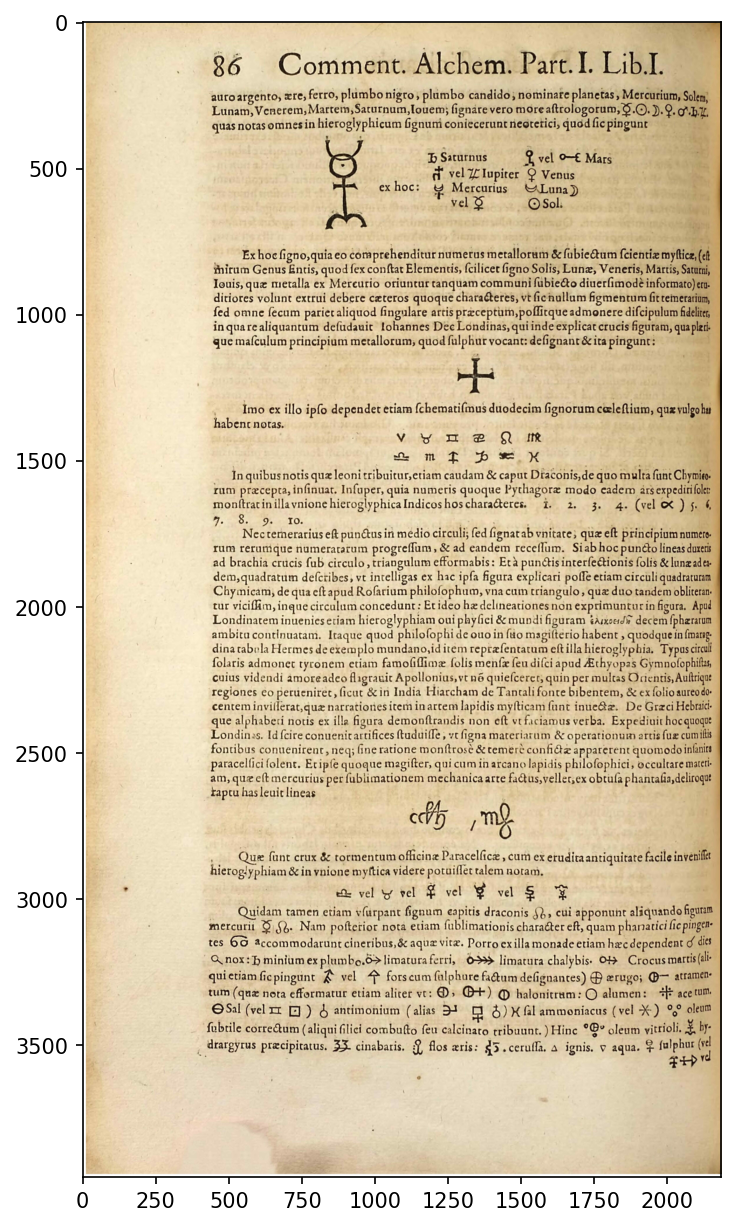

In [244]:
p = doc_pdf.load_page(96)
pix = p.get_pixmap()
np_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n) # if you need an image
fig, ax = plt.subplots(figsize=(10, 10), dpi=150)
ax.imshow(np_array)
plt.show()

In [245]:
def get_token_coordinates(token, textblocks):
    """
    Returns the coordinates (x0, y0, x1, y1) of the ORIGINAL OCR textblock
    that produced the token.

    token.ref MUST contain:
        - "page": [int]
        - "textblock": [int]
    """

    ref = token["ref"]
    if ref is None:
        return None

    page_list = ref.get("page")
    tb_list = ref.get("textblock")

    if not page_list or not tb_list:
        return None

    page_idx = page_list[0]
    tb_idx = tb_list[0]

    try:
        tb = textblocks[page_idx][tb_idx]
        return tb["coordinates"]
    except Exception as e:
        print("Coordinate lookup failed:", e)
        return None

def attach_coordinates_to_sent_dicts(sent_dicts, textblocks):
    for sent in sent_dicts:
        for tok in sent["tokens_data"]:
            tok["coordinates"] = get_token_coordinates(tok, textblocks)
    return sent_dicts

In [246]:
sent_dicts_with_coords = attach_coordinates_to_sent_dicts(sent_dicts, textblocks)
sent_dicts_margins_with_coords = attach_coordinates_to_sent_dicts(sent_dicts_margins, textblocks)

In [247]:
[textblock for textblock in textblocks[4] if textblock["tag"] in ["header", "title", "text"]]

[{'coordinates': [752.6400146484375,
   171.59994506835938,
   1860.423095703125,
   176.3999481201172],
  'text': 'EPISTOLA DEDICATORIA. ',
  'tag': 'header'},
 {'coordinates': [420.0,
   255.35995483398438,
   2208.9599609375,
   260.1599426269531],
  'text': 'test ex sequentibus intelligi. Triplex hodiè est medicinae docendae, facien',
  'tag': 'text'},
 {'coordinates': [424.79998779296875,
   334.7998962402344,
   2193.759765625,
   339.5998840332031],
  'text': 'daeque & ratio & familia. Primam appellant sectam dogmaticorum & ',
  'tag': 'text'},
 {'coordinates': [420.0,
   408.9839172363281,
   2192.752685546875,
   413.9039306640625],
  'text': 'rationalium, cuius professores ab Hippocrate & Galeno Hippocratici & ',
  'tag': 'text'},
 {'coordinates': [434.6400146484375,
   490.5599060058594,
   2202.1669921875,
   495.3598937988281],
  'text': 'Galenici nuncupantur, quia potissmum, istorum, instituta sequuntur. ',
  'tag': 'text'},
 {'coordinates': [429.6000061035156,
   570.000

In [248]:
[sent["sent_text"] for sent in sent_dicts_with_coords if sent["tokens_data"][-1]["ref"]["page"][-1]==96]

['Itaque nihil hodie est usitatius, quam pro septem metallis, hoc est, hydrargyro, image1 auro argento, aere, ferro, plumbo nigro, plumbo candido, nominare planetas, Mercurium, Solem, Lunam, Uenerem, Martem, Saturnum, louem;',
 'signare uero more astrologorum, ◉, ◉, ◉, ◉, ◉, ◉, ◉.',
 'quas notas omnes in hieroglyphicum signum coniecerunt neoterici, quòd sic pingunt ex hoc:',
 '◉ Saturnus ◉ uel ◉.',
 'Iupiter ◉ Mercurius uel ◉ ◉ uel ◉ Mars ◉ Uenus ◉ Luna ◉ ◉ Sol.',
 'Ex hoc signo, quia eo comprehenditur numerus metallorum & subiectum scientiae mysticae, (est mirum Genus Entis, quod sex constat Elementis, scilicet signo Solis, Lunae, Ueneris, Martis, Saturni, Iouis, quae metalla ex Mercurio oriuntur tanquam communi subiecto diuersimodè informato) eruditiores uolunt extrui debere caeteros quoque characteres, ut sic nullum figmentum sit temerarium sed omne secum pariet aliquod singulare artis praeceptùm, possitque admonere discipulum fideliter, in qua re aliquantum desudauit Iohannes Dee L

In [249]:
sent_dicts_margins_with_coords[:5]

[{'work_id': '100085',
  'sent_id': 0,
  'sent_text': 'In specie tot medicorum hodie sectae, ut uideantur innumerabila, genere ad tres classes reduci possunt.',
  'tokens_data': [{'token_text': 'In',
    'lemma': 'in',
    'pos': 'ADP',
    'ref': {'page': [4], 'textblock': [0], 'tags': [], 'blocktype': 'margin'},
    'char_start': 0,
    'char_end': 2,
    'coordinates': [235.44000244140625,
     684.7200317382812,
     409.4384460449219,
     689.5200805664062]},
   {'token_text': 'specie',
    'lemma': 'species',
    'pos': 'NOUN',
    'ref': {'page': [4], 'textblock': [0], 'tags': [], 'blocktype': 'margin'},
    'char_start': 3,
    'char_end': 9,
    'coordinates': [235.44000244140625,
     684.7200317382812,
     409.4384460449219,
     689.5200805664062]},
   {'token_text': 'tot',
    'lemma': 'tot',
    'pos': 'DET',
    'ref': {'page': [4], 'textblock': [0], 'tags': [], 'blocktype': 'margin'},
    'char_start': 10,
    'char_end': 13,
    'coordinates': [235.44000244140625,
  

In [250]:
page_sents = [sent for sent in sent_dicts_with_coords if sent["tokens_data"][-1]["ref"]["page"][-1]==96]

page_margins = [sent for sent in sent_dicts_margins_with_coords if sent["tokens_data"][-1]["ref"]["page"][0]==96]


In [251]:
[sent["sent_text"] for sent in page_sents[:10]]

['Itaque nihil hodie est usitatius, quam pro septem metallis, hoc est, hydrargyro, image1 auro argento, aere, ferro, plumbo nigro, plumbo candido, nominare planetas, Mercurium, Solem, Lunam, Uenerem, Martem, Saturnum, louem;',
 'signare uero more astrologorum, ◉, ◉, ◉, ◉, ◉, ◉, ◉.',
 'quas notas omnes in hieroglyphicum signum coniecerunt neoterici, quòd sic pingunt ex hoc:',
 '◉ Saturnus ◉ uel ◉.',
 'Iupiter ◉ Mercurius uel ◉ ◉ uel ◉ Mars ◉ Uenus ◉ Luna ◉ ◉ Sol.',
 'Ex hoc signo, quia eo comprehenditur numerus metallorum & subiectum scientiae mysticae, (est mirum Genus Entis, quod sex constat Elementis, scilicet signo Solis, Lunae, Ueneris, Martis, Saturni, Iouis, quae metalla ex Mercurio oriuntur tanquam communi subiecto diuersimodè informato) eruditiores uolunt extrui debere caeteros quoque characteres, ut sic nullum figmentum sit temerarium sed omne secum pariet aliquod singulare artis praeceptùm, possitque admonere discipulum fideliter, in qua re aliquantum desudauit Iohannes Dee L

In [252]:
page_margins[:5]

[]

In [253]:
patch_color_dict = {"title" : "green",
                    "header" : "red",
                    "footer" : "orange",
                    "margin" : "yellow",
                     "text" : "white",
}

def plot_patch(coords, blocktype, ax):
   color = patch_color_dict[blocktype]
   patch = patches.Rectangle((coords[0], coords[1]),  # Bottom left corner
                              coords[2] - coords[0],  # Width
                              coords[3] - coords[1],  # Height
                              linewidth=1, edgecolor=color, facecolor='none')
   ax.add_patch(patch) # draw candidate textblocks in black

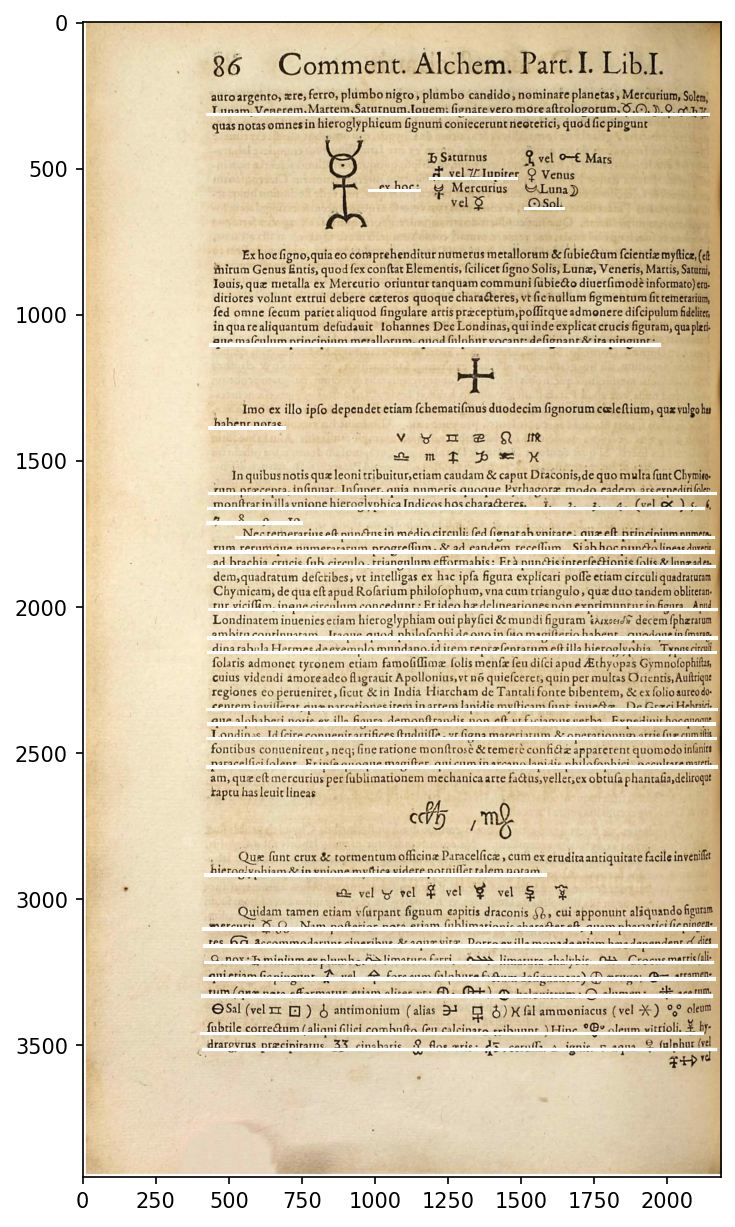

In [254]:
fig, ax = plt.subplots(figsize=(10, 10), dpi=150)
ax.imshow(np_array)

for sent in page_sents:
    last_token_coords =  sent["tokens_data"][-1]["coordinates"]
    plot_patch(last_token_coords, "text", ax)

for sent in page_margins:
    first_token_coords =  sent["tokens_data"][0]["coordinates"]
    plot_patch(first_token_coords, "margin", ax)

plt.show()

In [255]:
def merge_main_and_margin_sentences(
    sent_dicts_with_coords,
    sent_dicts_margins_with_coords
):
    """
    Returns a *single merged list* of sentence dicts,
    where margin sentences are inserted after the main-text
    sentences whose last-token y0 is VERTICALLY NEAREST
    to the first-token y0 of the margin sentence (on the same page).

    MAIN SENTENCE anchor_y  = last_token.coordinates[1]
    MARGIN SENTENCE anchor_y = first_token.coordinates[1]
    """

    from collections import defaultdict

    main_by_page = defaultdict(list)
    margin_by_page = defaultdict(list)

    # --- 1. Main text: anchor = y of last token ---
    for s in sent_dicts_with_coords:
        if not s.get("tokens_data"):
            continue

        last_tok = s["tokens_data"][-1]
        coords = last_tok.get("coordinates")
        if coords is None:
            continue

        page = last_tok["ref"]["page"][-1]
        s["_anchor_y"] = float(coords[1])  # y0 of last token
        s["_page"] = page
        main_by_page[page].append(s)

    # --- 2. Margins: anchor = y of *first* token ---
    for s in sent_dicts_margins_with_coords:
        if not s.get("tokens_data"):
            continue

        first_tok = s["tokens_data"][0]
        coords = first_tok.get("coordinates")
        if coords is None:
            continue

        page = first_tok["ref"]["page"][0]
        s["_anchor_y"] = float(coords[1])  # y0 of first token
        s["_page"] = page
        margin_by_page[page].append(s)

    merged = []
    all_pages = sorted(set(main_by_page.keys()) | set(margin_by_page.keys()))

    for page in all_pages:
        mains = main_by_page.get(page, [])
        margins = margin_by_page.get(page, [])

        # If there is no main text on this page, just append margins in vertical order
        if not mains:
            for m in sorted(margins, key=lambda s: s["_anchor_y"]):
                merged.append(m)
            continue

        # Sort main sentences by their anchor_y
        mains_sorted = sorted(mains, key=lambda s: s["_anchor_y"])

        # Prepare: list of lists of margins to attach after each main
        attach_after = {i: [] for i in range(len(mains_sorted))}

        # For each margin, find nearest main *on that page*
        for m in margins:
            m_y = m["_anchor_y"]

            best_i = None
            best_dist = float("inf")
            for i, main_s in enumerate(mains_sorted):
                dist = abs(main_s["_anchor_y"] - m_y)
                if dist < best_dist:
                    best_dist = dist
                    best_i = i

            # Attach margin AFTER that main sentence
            attach_after[best_i].append(m)

        # Interleave: main, then all margins attached to it
        out_page = []
        for i, main_s in enumerate(mains_sorted):
            out_page.append(main_s)
            if attach_after[i]:
                out_page.extend(attach_after[i])

        merged.extend(out_page)

    # --- Cleanup temp fields + reassign global sent_id ---
    for new_id, s in enumerate(merged):
        s["sent_id"] = new_id
        s.pop("_anchor_y", None)
        s.pop("_page", None)

    return merged

In [256]:
page_merged_sentences = merge_main_and_margin_sentences(
    page_sents,
    page_margins
)

In [257]:
page_margin_integration_example_sents = pd.DataFrame([(sent["sent_text"], sent["tokens_data"][0]["ref"]["blocktype"]) for sent in page_merged_sentences])
page_margin_integration_example_sents.head(50)

,0,1
0,"Itaque nihil hodie est usitatius, quam pro sep...",text
1,"signare uero more astrologorum, ◉, ◉, ◉, ◉, ◉,...",text
2,◉ Saturnus ◉ uel ◉.,text
3,quas notas omnes in hieroglyphicum signum coni...,text
4,Iupiter ◉ Mercurius uel ◉ ◉ uel ◉ Mars ◉ Uenus...,text
5,"Ex hoc signo, quia eo comprehenditur numerus m...",text
6,quod sulphur uocant:,text
7,designant & ita pingunt:,text
8,◉ Imo ex illo ipso dependet etiam schematismus...,text
9,◉ ◉ ◉ ◉ ◉ ◉ ◉ ◉ ◉ ◉ ◉ ◉ In quibus notis quae l...,text


In [258]:
#google_conf.set_with_dataframe(emlap_catalogue.add_worksheet("page_sents_example_p96", 1,1), page_margin_integration_example_sents)

In [259]:
page_tokens_example = pd.DataFrame(
    (lambda d, n=n: (d.update({"sent_n": n}) or d))(t)
    for n, token_list in enumerate([sent["tokens_data"] for sent in page_merged_sentences])
    for t in token_list
)
for attr in ["page", "textblock", "tags", "blocktype"]:
    page_tokens_example[attr] = page_tokens_example.apply(lambda row: row["ref"][attr], axis=1)
page_tokens_example.drop(["ref", "coordinates"], axis=1, inplace=True)
page_tokens_example.head(5)

,token_text,lemma,pos,char_start,char_end,sent_n,page,textblock,tags,blocktype
0,Itaque,itaque,CCONJ,0,6,0,[95],[65],[],text
1,nihil,nihil,PRON,7,12,0,[95],[65],[],text
2,hodie,hodie,ADV,13,18,0,[95],[65],[],text
3,est,sum,AUX,19,22,0,[95],[65],[],text
4,usitatius,usitatior,ADJ,23,32,0,[95],[65],[],text


In [260]:
google_conf.set_with_dataframe(emlap_catalogue.add_worksheet("page_tokens_example_libavius_p96_symbols", 1,1), page_tokens_example)

In [334]:
textblocks[96][2:5]

[{'coordinates': [424.0799865722656,
   263.3039855957031,
   2160.621826171875,
   268.2239990234375],
  'text': 'auro argento, aere, ferro, plumbo nigro, plumbo candido, nominare planetas, Mercurium, Solem,\n',
  'tag': 'text'},
 {'coordinates': [424.0799865722656,
   312.7200622558594,
   2143.775634765625,
   317.5200500488281],
  'text': 'Lunam, Venerem, Martem, Saturnum, louem; signare vero more astrologorum,\xa0[S]Mercurius[/S],\xa0[S]Sol[/S],\xa0[S]Luna[/S],\xa0[S]Venus[/S],\xa0[S]Mars[/S],\xa0[S]Saturnus[/S],\xa0[S]Jupiter[/S].\n',
  'tag': 'text'},
 {'coordinates': [428.3999938964844,
   360.7200622558594,
   1958.1298828125,
   365.5200500488281],
  'text': 'quas notas omnes in hieroglyphicum signum coniecerunt neoterici, quòd sic pingunt\n',
  'tag': 'text'}]

In [314]:
sent_dicts_with_coords = attach_coordinates_to_sent_dicts(sent_dicts, textblocks)
sent_dicts_margins_with_coords = attach_coordinates_to_sent_dicts(sent_dicts_margins, textblocks)

merged_sentences = merge_main_and_margin_sentences(
    sent_dicts_with_coords,
    sent_dicts_margins_with_coords
)

In [315]:
len(merged_sentences)

7638

In [316]:
merged_tokens = pd.DataFrame(
    (lambda d, n=n: (d.update({"sent_n": n}) or d))(t)
    for n, token_list in enumerate([sent["tokens_data"] for sent in merged_sentences])
    for t in token_list
)
for attr in ["page", "textblock", "tags", "blocktype"]:
    merged_tokens[attr] = merged_tokens.apply(lambda row: row["ref"][attr], axis=1)
merged_tokens.drop(["ref", "coordinates"], axis=1, inplace=True)
merged_tokens.head(5)

,token_text,lemma,pos,char_start,char_end,sent_n,page,textblock,tags,blocktype
0,Commentariorum,commentarius,NOUN,0,14,0,[1],[1],[],text
1,Alchymiae,alchymius,PROPN,0,9,1,[1],[2],[],title
2,Andreae,Andreas,ADJ,0,7,2,[1],[3],[],text
3,Libauii,Libauii,PROPN,8,15,2,[1],[3],[],text
4,Med,ego,PROPN,16,19,2,[1],[3],[],text


In [317]:
len(merged_tokens)

99679

In [318]:
merged_tokens[merged_tokens["tags"].apply(lambda x: "G" in x)][:10]


,token_text,lemma,pos,char_start,char_end,sent_n,page,textblock,tags,blocktype
91659,vil,vil,ADP,7,10,6969,[91],[64],[G],text
91660,besser,gut,ADV,11,17,6969,[91],[64],[G],text
91661,daß,daß,SCONJ,18,21,6969,[91],[64],[G],text
91662,das,der,DET,22,25,6969,[91],[64],[G],text
91663,weiber,weiber,ADV,26,32,6969,[91],[64],[G],text
91664,uolck,Uolck,NOUN,33,38,6969,[91],"[64, 65]",[G],text
91683,geringe,gering,ADJ,28,35,6970,[91],"[65, 66]",[G],text
91684,haußhaltung,Haußhaltung,NOUN,36,47,6970,[91],[66],[G],text
91685,ist,sein,AUX,48,51,6970,[91],[66],[G],text
91687,gebuerth,Gebuerth,PROPN,54,62,6970,[91],[66],[G],text


In [319]:
print(merged_tokens[merged_tokens["tags"].apply(lambda x: "S" in x)].head(10))

      token_text     lemma    pos  char_start  char_end  sent_n  page  \
43471          y        ym      X           5         6    3109  [48]   
74001       iiii      iiii    NUM          11        15    5680  [74]   
95873        Sol       sol  PROPN          43        46    7216  [96]   
95875       Luna      luna  PROPN          48        52    7216  [96]   
95877      Venus     Uenus  PROPN          54        59    7216  [96]   
95879       Mars      Mars  PROPN          61        65    7216  [96]   
95881   Saturnus  Saturnus  PROPN          67        75    7216  [96]   
95883    Jupiter   Jupiter  PROPN          77        84    7216  [96]   
95885       quas       qui   PRON           0         4    7217  [96]   
95886      notas      noto   NOUN           5        10    7217  [96]   

      textblock tags blocktype  
43471       [0]  [S]    margin  
74001      [31]  [S]      text  
95873       [3]  [S]      text  
95875       [3]  [S]      text  
95877       [3]  [S]      text 

In [320]:
textblocks[96][3]

{'coordinates': [424.0799865722656,
  312.7200622558594,
  2143.775634765625,
  317.5200500488281],
 'text': 'Lunam, Venerem, Martem, Saturnum, louem; signare vero more astrologorum,\xa0[S]Mercurius[/S],\xa0[S]Sol[/S],\xa0[S]Luna[/S],\xa0[S]Venus[/S],\xa0[S]Mars[/S],\xa0[S]Saturnus[/S],\xa0[S]Jupiter[/S].\n',
 'tag': 'text'}

In [107]:
def process_file_to_v2_json(filepath, work_id, outpath, nlp):
    """
    Load OCR textblocks → build Doc → convert to v2 sentence dicts → write JSON.
    """

    # Load textblocks
    with open(filepath, 'r', encoding='utf-8') as f:
        textblocks_pages = json.load(f)

    # Build annotated doc
    doc = process_with_source_tracking(textblocks_pages, nlp)

    # Convert doc to sentence dictionaries
    sent_dicts = doc_to_sent_dicts(doc, work_id)

    # Write JSON
    with open(outpath, "w", encoding="utf-8") as f:
        json.dump(sent_dicts, f, ensure_ascii=False, indent=2)

In [109]:
sent_dicts_with_coords = attach_coordinates_to_sent_dicts(sent_dicts, textblocks)
sent_dicts_margins_with_coords = attach_coordinates_to_sent_dicts(sent_dicts_margins, textblocks)

merged_sentences = merge_main_and_margin_sentences(
    sent_dicts_with_coords,
    sent_dicts_margins_with_coords
)

In [111]:
merged_sentences[20:25]

[{'work_id': '100085',
  'sent_id': 20,
  'sent_text': 'ExpeRientia Excellentissimo Uiro, Et',
  'tokens_data': [{'token_text': 'ExpeRientia',
    'lemma': 'experientia',
    'pos': 'PROPN',
    'ref': {'page': [3],
     'textblock': [1, 2],
     'tags': None,
     'blocktype': 'title'},
    'char_start': 0,
    'char_end': 11,
    'coordinates': [194.16000366210938,
     1076.4000244140625,
     1926.0487060546875,
     1081.199951171875]},
   {'token_text': 'Excellentissimo',
    'lemma': 'excellentissimus',
    'pos': 'PROPN',
    'ref': {'page': [3], 'textblock': [2], 'tags': None, 'blocktype': 'title'},
    'char_start': 12,
    'char_end': 27,
    'coordinates': [156.24000549316406,
     1152.2401123046875,
     1933.520751953125,
     1157.0400390625]},
   {'token_text': 'Uiro',
    'lemma': 'uiro',
    'pos': 'NOUN',
    'ref': {'page': [3], 'textblock': [2], 'tags': None, 'blocktype': 'title'},
    'char_start': 28,
    'char_end': 32,
    'coordinates': [156.24000549316406,
 

In [ ]:
source_path = "../data/emlap_annotated_textblocks/"
target_path = "../data/sents_data_jsons_dicts/"
os.makedirs(target_path, exist_ok=True)

for filename in os.listdir(source_path):

    if not filename.endswith(".json"):      # textblocks files
        continue

    work_id = filename[:6]
    outpath = os.path.join(target_path, f"{work_id}.json")

    # Skip if already processed
    if os.path.exists(outpath):
        continue

    filepath = os.path.join(source_path, filename)
    print("Processing", filename)

    try:
        process_file_to_v2_json(
            filepath=filepath,
            work_id=work_id,
            outpath=outpath,
            nlp=tomela.nlp
        )
    except Exception as e:
        print("FAILED:", filename, "→", e)

In [98]:
sent_data_updated[100:120]

[('100085',
  100,
  'Non alium liquorem uesica reddunt.',
  [('Non',
    'non',
    'PART',
    (0, 3),
    {'page': [7], 'texblock': [23], 'tags': None, 'blocktype': 'text'}),
   ('alium',
    'alius',
    'DET',
    (4, 9),
    {'page': [7], 'texblock': [23], 'tags': None, 'blocktype': 'text'}),
   ('liquorem',
    'liquor',
    'NOUN',
    (10, 18),
    {'page': [7], 'texblock': [23], 'tags': None, 'blocktype': 'text'}),
   ('uesica',
    'uesica',
    'NOUN',
    (19, 25),
    {'page': [7], 'texblock': [23, 24], 'tags': None, 'blocktype': 'text'}),
   ('reddunt',
    'reddo',
    'VERB',
    (26, 33),
    {'page': [7], 'texblock': [24], 'tags': None, 'blocktype': 'text'}),
   ('.',
    '.',
    'PUNCT',
    (33, 34),
    {'page': [7], 'texblock': [24], 'tags': None, 'blocktype': 'text'})]),
 ('100085',
  101,
  'Non habent alia membra, quam nos, non sudores alios.',
  [('Non',
    'non',
    'PART',
    (0, 3),
    {'page': [7], 'texblock': [24], 'tags': None, 'blocktype': 'text'}

In [ ]:
    target_path = "/srv/data/tome/tome-corpus/sents_data_id_jsons_v4-0/"
os.makedirs(target_path, exist_ok=True)

In [ ]:
# filename_id_dict.items()

In [ ]:
source_path = "../data/emlap_annotated_textblocks/"
len(os.listdir(source_path)) # 100 for textblocks, 100 for parameters used for their extraction

In [ ]:
os.listdir(source_path)

In [ ]:
for filename in os.listdir(source_path):
    if "_params" not in filename:
            id = filename[:6]
            try:
                if id + ".json" not in os.listdir(target_path):
                    # filename = filename.replace(".pdf", ".json")
                    filepath = os.path.join(source_path, filename)
                    with open(filepath, 'r', encoding='utf-8') as f:
                            textblocks_pages = json.load(f)
                    print("currently processing: ", filename)
                    doc = process_with_source_tracking(textblocks_pages, tomela.nlp)
                    doc_sentdata = [(sent.text, [(t.text, t.lemma_, t.pos_, (t.idx - sent[0].idx, t.idx - sent[0].idx + len(t)),  {"page" : t._.pages, "texblock" : t._.textblocks}) for t in sent]) for sent in doc.sents]
                    sent_data_updated = []
                    for n_sent, sent_data in enumerate(doc_sentdata):
                            sent_data_updated.append((id, n_sent, sent_data[0], sent_data[1]))
                    with open(target_path + str(id) + ".json", "w") as f:
                            json.dump(sent_data_updated, f)
            except:
                print("failed with file: ", id, filename)
                pass

In [ ]:
fns_jsons = os.listdir(target_path)
fns_jsons[:10]

In [ ]:
len(fns_jsons)

In [ ]:
sents_data = json.load(open(target_path + fns_jsons[20], "r"))
sents_data[100:103]

In [ ]:
import os, json, pickle
prev_path   = target_path  # where your old .pickle / .json live
target_path = "../data/sents_data_jsons_dicts/"
os.makedirs(target_path, exist_ok=True)

def token_tuple_to_dict(tok):
    """
    Accepts token tuples of length 4 or 5:
      4: (text, lemma, pos, (start, end))
      5: (text, lemma, pos, (start, end), ref_dict)
    Returns a JSON-serializable dict.
    """
    if len(tok) < 4:
        raise ValueError(f"Unexpected token shape: {tok}")

    token_text, lemma, pos, span = tok[0], tok[1], tok[2], tok[3]
    if not isinstance(span, (list, tuple)) or len(span) != 2:
        raise ValueError(f"Bad span in token: {tok}")

    char_start, char_end = int(span[0]), int(span[1])

    # Optional ref at index 4
    ref = tok[4] if len(tok) >= 5 else None

    # Make sure ref is JSON-friendly
    if isinstance(ref, dict):
        page = ref.get("page")
        # convert sets/tuples to lists to be JSON-serializable
        if isinstance(page, (set, tuple)):
            page = list(page)
        ref = {
            "page": page,
            "textblock": ref.get("textblock") or ref.get("texblock")  # tolerate earlier key name
        }
    elif ref is not None:
        # unexpected type → stringify to avoid JSON errors
        ref = str(ref)

    return {
        "token_text": token_text,
        "lemma": lemma,
        "pos": pos,
        "ref": ref,                  # << stays None if we don’t have it
        "char_start": char_start,
        "char_end": char_end,
    }

def sent_tuple_to_dict(entry):
    """
    entry is typically: (work_id, sent_id, sent_text, tokens_list)
    """
    if len(entry) != 4:
        raise ValueError(f"Unexpected sentence shape: {type(entry)} {entry}")

    work_id, sent_id, sent_text, tokens_list = entry
    tokens_dicts = [token_tuple_to_dict(tok) for tok in tokens_list]
    return {
        "work_id": work_id,
        "sent_id": int(sent_id),
        "sent_text": sent_text,
        "tokens_data": tokens_dicts,
    }

def load_any(path):
    """
    Load .pickle OR .json produced by your previous run.
    Must return a list of sentence entries (tuples/lists).
    """
    if path.endswith(".pickle"):
        with open(path, "rb") as f:
            return pickle.load(f)
    elif path.endswith(".json"):
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    else:
        raise ValueError(f"Unsupported file type: {path}")

for fn in os.listdir(prev_path):
    if not (fn.endswith(".pickle") or fn.endswith(".json")):
        continue

    # Keep your 6-char doc id convention if you like
    doc_id = fn[:6]
    out_path = os.path.join(target_path, f"{doc_id}.json")
    if os.path.exists(out_path):
        continue

    try:
        prev_data = load_any(os.path.join(prev_path, fn))
        # If the previous version stored only (sent_text, tokens) per sentence,
        # reconstruct work_id/sent_id here as needed:
        # e.g., prev_data == [(sent_text, tokens), ...]
        if prev_data and len(prev_data[0]) == 2:
            # synthesize (work_id, sent_id, sent_text, tokens)
            prev_data = [(doc_id, i, s[0], s[1]) for i, s in enumerate(prev_data)]

        sents_dicts = [sent_tuple_to_dict(row) for row in prev_data]

        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(sents_dicts, f, ensure_ascii=False, indent=2)

        print("wrote:", out_path)

    except Exception as e:
        print("failed:", fn, "-", e)

In [32]:
doc, doc_margins = process_with_source_tracking(textblocks[:20], tomela.nlp)

In [ ]:
lemmatized_sents_path = "/srv/data/tome/tome-corpus/lemmatized_sents_v4-0/"
try:
    os.mkdir(lemmatized_sents_path)
except:
    pass

In [ ]:
os.listdir(lemmatized_sents_path)

In [ ]:
for fn in fns_jsons:
    lemmatized_sents = []
    sents_data = json.load(open(target_path + fn, "rb"))
    print(fn)
    for (doc_id, sent_id, sent_text, sent_data) in sents_data:
        lemmasent = []
        for wordform, lemma, tag, position, t_ref in sent_data:
            if tag in ["NOUN", "PROPN", "ADJ", "VERB"]:
                lemmasent.append(lemma.lower())
        lemmatized_sents.append(" ".join(lemmasent) + "\n")
    with open(lemmatized_sents_path + fn.replace(".json", ".txt"), "w", encoding="utf-8") as f:
        f.writelines(lemmatized_sents)

In [ ]:
import shutil
shutil.copytree("/srv/data/tome/tome-corpus/lemmatized_sents_v4-0/", "../data/lemmatized_sents", dirs_exist_ok=True)
shutil.copytree("/srv/data/tome/tome-corpus/sents_data_id_jsons_v4-0/", "../data/sents_data", dirs_exist_ok=True)